In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Unless otherwise defined, these are the settings used for testing the barriers
substrate = "3_bromoquinoline"   # case1 substrate
ligand    = "PCy3"               # ligand
T         = 110               # temperature in Celsius
case      = "case1"
ligand_list = ["PCy3", "PPh3", "AmPhos", "Catacxium_A", "RuPhos", "SPhos", "tBu3", "XPhos"]
substrate_list = ["3_bromoquinoline", "2_chloropyridine", "3_chloropyridine"]
temperature_list = [30, 50, 70, 90, 110]
case_list = ["case1", "case2", "case3", "case4"]
dict_tm_case = {
    'case1': ('3_bromoquinoline', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case2': ('3_chloropyridine', 'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid', 'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate'),
    'case3': ('3_chloropyridine', 'BOH2Ar_compound_6_benzofuran-2-boronic_acid', 'BPinAr_compound_6_benzofuran-2-boronate'),
    'case4': ('2_chloropyridine', 'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid', 'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate'),
}

In [7]:
# Helper: look up G for a species at a given temperature
def get_G(df, species_name, temperature_C):
    row = df[(df["species_name"] == species_name) & (df["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol"].values[0] 

def get_G_old(df_old, species_name, temperature_C):
    row = df_old[(df_old["species_name"] == species_name) & (df_old["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["G_total_AIMNet_msrrho_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_reactant9(df_reactant9, species_name, temperature_C):
    row = df_reactant9[(df_reactant9["species"] == species_name) & (df_reactant9["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0]

def get_G_reactant8(df_reactant8, species_name, temperature_C):
    row = df_reactant8[(df_reactant8["species"] == species_name) & (df_reactant8["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] # Before: G_total_wb97mv_plus_Gcorr_plus_SMDTHF_kcal_mol

def get_G_BOH3(df_BOH3, species_name, temperature_C):
    row = df_BOH3[(df_BOH3["species"] == species_name) & (df_BOH3["temperature_C"] == temperature_C)]
    if row.empty:
        raise ValueError(f"Species {species_name!r} not found at {temperature_C} C")
    return row["Gtotal_wB97MV_gas_SPE_AIMNet2PD_msRRHO_Gsolv_THF_kcal_mol"].values[0] 

def plotting_TM_barriers_with_react9(ligand, case, T):
    substrate = dict_tm_case[case][0]
    results_ligand = TM_barriers_with_react9(ligand, case, T)
    labels_tm   = ["2*PdLArOH + \n ArB(OH)2","TM_reactant_8 + \n ArB(OH)2", "TM_reactant_9", "TM_reactant_10 + \n PdLArOH", "TM_reactant + \n PdLArOH", "TM_TS + \n PdLArOH", "TM_product\n+ BOH3 + PdLArOH"]
    energies_tm = [0.0, results_ligand["dG_TM_react_8"], results_ligand["dG_TM_reactant_9"], results_ligand["dG_TM_reactant_10"], results_ligand["dG_TM_reactant"], results_ligand["dG_TM_TS"], results_ligand["dG_TM_product"]]
    x = [0, 1, 2, 3, 4, 5, 6]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
    for xi, yi, lbl in zip(x, energies_tm, labels_tm):
        ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                    textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_tm, fontsize=9)
    ax.set_ylabel("dG (kcal/mol)")
    ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
    ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C")
    plt.tight_layout()
    plt.show()

In [ ]:
full_path = r"FINAL-Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new_reduced_all_methods.csv"
df = pd.read_csv(full_path)

# full_path_old = r"Reizmann_AIMNet_Gtotal_msrrho_20C_120C_all_species_new.csv"
# df_old = pd.read_csv(full_path_old)

df_reactant9 = pd.read_csv(r"TM9_FINAL\TM9_FINAL\tables\TM9_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol_plus8_species_plus5_SPE-FINAL.csv")

df_reactant8 = pd.read_csv(r"TM8_FINAL\TM8_FINAL\tables\TM8_Gtotal_msrrho_20C_120C_FINAL.csv")

df_BOH3 = pd.read_csv(r"BOH3_neutral_recalc\BOH3_neutral_recalc\tables\BOH3_Gtotal_msrrho_20C_120C_all_species_wide_kcalmol.csv")

COMPARISON: Without vs With Standard State Corrections (1 bar vs 1 M)

--- WITHOUT corrections (1 bar standard state) ---


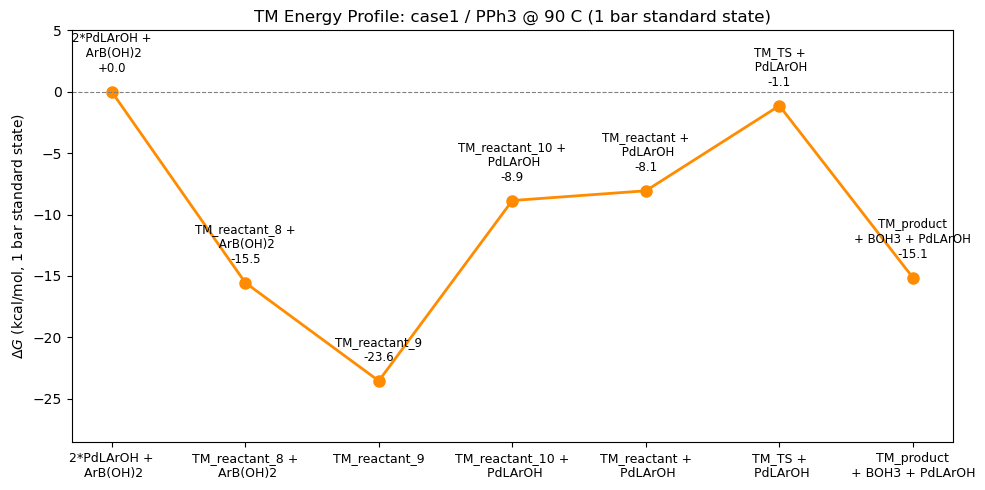


--- WITH corrections (1 M standard state) ---


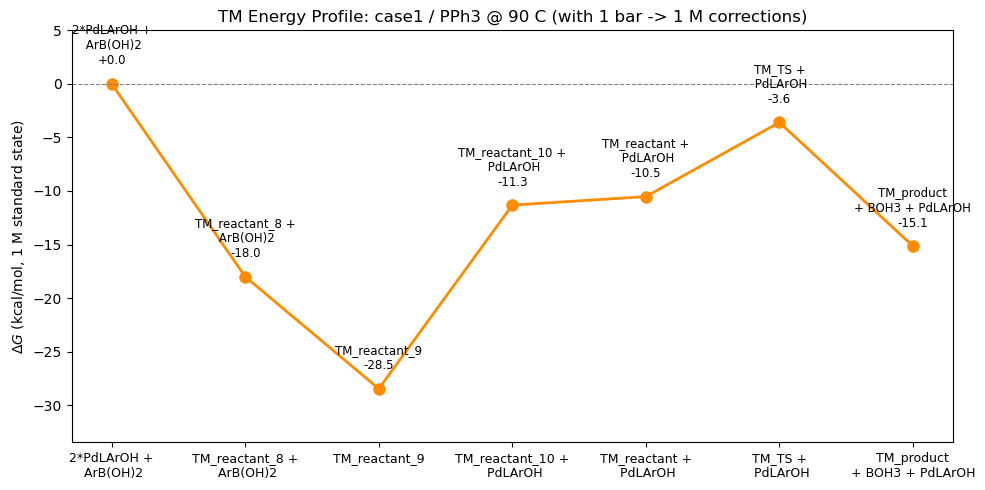


RUNNING FULL ANALYSIS WITH STANDARD STATE CORRECTIONS
  Skipping (AmPhos, case1) @ 30°C: Species 'TM_reactant_case1_AmPhos_as_9' not found at 30 C
  Skipping (RuPhos, case1) @ 30°C: Species 'TM8_OH_3_bromoquinoline_RuPhos' not found at 30 C

Completed TM barrier calculations for T = 30 C (with 1 M corrections)

=== 3_bromoquinoline / PCy3 @ 30 C ===
  Total barrier: +34.04 kcal/mol (1 M standard state)

=== 3_chloropyridine / PCy3 @ 30 C ===
  Total barrier: +24.82 kcal/mol (1 M standard state)

=== 3_chloropyridine / PCy3 @ 30 C ===
  Total barrier: +32.42 kcal/mol (1 M standard state)

=== 2_chloropyridine / PCy3 @ 30 C ===
  Total barrier: +33.82 kcal/mol (1 M standard state)

=== 3_bromoquinoline / PPh3 @ 30 C ===
  Total barrier: +28.51 kcal/mol (1 M standard state)

=== 3_chloropyridine / PPh3 @ 30 C ===
  Total barrier: +26.16 kcal/mol (1 M standard state)

=== 3_chloropyridine / PPh3 @ 30 C ===
  Total barrier: +29.11 kcal/mol (1 M standard state)

=== 2_chloropyridine / PPh3 

In [ ]:
# Add this function to read standard state correction factors
def load_standard_state_corrections(csv_path):
    """Load standard state correction factors from CSV."""
    df_corrections = pd.read_csv(csv_path)
    return df_corrections

def get_standard_state_correction(df_corrections, temperature_C, delta_n):
    """
    Get the standard state correction for a given temperature and delta_n.
    
    Parameters:
    -----------
    df_corrections : DataFrame
        DataFrame with standard state correction values
    temperature_C : float
        Temperature in Celsius
    delta_n : int
        Change in number of species (n_at_point - n_reference)
    
    Returns:
    --------
    correction : float
        Standard state correction in kcal/mol
    """
    row = df_corrections[df_corrections["temperature_C"] == temperature_C]
    if row.empty:
        raise ValueError(f"Temperature {temperature_C} C not found in correction file")
    
    c_T = row["c_1bar_to_1M_per_molecule_kcal_mol"].values[0]
    
    return delta_n * c_T

# Updated TM_barriers_with_react9 function with standard state corrections
def TM_barriers_with_react9(ligand, case, T, apply_standard_state_correction=True, df_corrections=None, verbose=False):
    """
    Calculate transmetalation barriers including dimers 8 and 9.
    
    Now with standard state correction from 1 bar to 1 M.
    Reference state: 2*PdLArOH + ArB(OH)2 (3 species, 1 bar)
    
    For each point:
        Delta n = number_of_species_at_point - 3
        correction = Delta n * c(T)
        Delta G_1M = Delta G_1bar + correction
    """
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
        substrate_concerted = "3_bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine"  # Needed for PdLArOH
        substrate_concerted = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 
        substrate_concerted = substrate

    # Fetch free energies (1 bar standard state from calculations)
    G_PdLArOH  = get_G(df, f"PdLArOH_{substrate_concerted}_{ligand}",  T)
    G_BOH2Ar   = get_G(df, dict_tm_case[case][1],             T)
    G_BOH3     = get_G_BOH3(df_BOH3, "BOH3_neutral", T)
    G_TM_react_10 = get_G(df, f"TM_reactant_{case}_{ligand}_as_10",    T)
    G_TM_react = get_G(df, f"TM_reactant_{case}_{ligand}",    T)
    G_TM_TS    = get_G(df, f"TM_TS_{case}_{ligand}",          T)
    G_TM_prod  = get_G(df, f"TM_product_{case}_{ligand}",     T)
    G_Bpin = get_G(df, dict_tm_case[case][2], T)
    G_H2O = get_G(df, "H2O", T)
    G_pinacol = get_G(df, "Pinacol", T)
    G_TM_react_9 = get_G_reactant9(df_reactant9, f"TM_reactant_{case}_{ligand}_as_9", T)
    G_TM_react_8 = get_G_reactant8(df_reactant8, f"TM8_OH_{substrate}_{ligand}", T)

    # Reference state: 3 species (2*PdLArOH + ArB(OH)2)
    G_ref_TM_sc1 = 2*G_PdLArOH + G_BOH2Ar
    n_reference = 3
    
    # Calculate 1 bar relative energies
    dG_TM_react_8_1bar = (G_TM_react_8 + G_BOH2Ar) - G_ref_TM_sc1
    dG_TM_react_9_1bar = G_TM_react_9 - G_ref_TM_sc1
    dG_TM_react_10_1bar = (G_TM_react_10 + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_react_1bar = (G_TM_react + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_TS_1bar = (G_TM_TS + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_prod_1bar = (G_TM_prod + G_BOH3 + G_PdLArOH) - G_ref_TM_sc1
    
    # Apply standard state corrections if requested
    if apply_standard_state_correction and df_corrections is not None:
        # Number of species at each point
        n_TM_react_8 = 2   # TM_react_8 + ArB(OH)2
        n_TM_react_9 = 1   # TM_react_9
        n_TM_react_10 = 2  # TM_react_10 + PdLArOH
        n_TM_react = 2     # TM_react + PdLArOH
        n_TM_TS = 2        # TS + PdLArOH
        n_TM_prod = 3      # TM_prod + BOH3 + PdLArOH
        
        # Calculate delta_n and corrections
        delta_n_dict = {
            'react_8': n_TM_react_8 - n_reference,
            'react_9': n_TM_react_9 - n_reference,
            'react_10': n_TM_react_10 - n_reference,
            'react': n_TM_react - n_reference,
            'TS': n_TM_TS - n_reference,
            'prod': n_TM_prod - n_reference
        }
        
        correction_dict = {}
        for key, delta_n in delta_n_dict.items():
            correction_dict[key] = get_standard_state_correction(df_corrections, T, delta_n)
        
        # Apply corrections to get 1 M energies
        dG_TM_react_8 = dG_TM_react_8_1bar + correction_dict['react_8']
        dG_TM_react_9 = dG_TM_react_9_1bar + correction_dict['react_9']
        dG_TM_react_10 = dG_TM_react_10_1bar + correction_dict['react_10']
        dG_TM_react = dG_TM_react_1bar + correction_dict['react']
        dG_TM_TS = dG_TM_TS_1bar + correction_dict['TS']
        dG_TM_prod = dG_TM_prod_1bar + correction_dict['prod']
        
        # Store corrections for verbose output
        corrections = correction_dict
        
    else:
        # No corrections applied (1 bar)
        dG_TM_react_8 = dG_TM_react_8_1bar
        dG_TM_react_9 = dG_TM_react_9_1bar
        dG_TM_react_10 = dG_TM_react_10_1bar
        dG_TM_react = dG_TM_react_1bar
        dG_TM_TS = dG_TM_TS_1bar
        dG_TM_prod = dG_TM_prod_1bar
        corrections = None
    
    # Calculate total barrier (max of TS relative to the most stable pre-complex)
    min_pre_complex = min(dG_TM_react_8, dG_TM_react_9, dG_TM_react_10, dG_TM_react)
    total_barrier = dG_TM_TS - min_pre_complex

    if verbose:
        print(f"TM Barrier Calculation: {substrate} / {ligand} @ {T} C")
        print("=" * 60)
        print()
        print("Reference state: 2*PdLArOH + ArB(OH)2 (3 species)")
        if apply_standard_state_correction and df_corrections is not None:
            print(f"Standard state correction applied: 1 bar -> 1 M")
            print(f"  c({T} C) = {get_standard_state_correction(df_corrections, T, 1):.4f} kcal/mol per molecule")
            print("  Corrections applied:")
            for key, corr in corrections.items():
                print(f"    {key}: Δn = {delta_n_dict[key]}, correction = {corr:+.4f} kcal/mol")
            print()
        print("Scenario 1: TM_reactant_10 as pre-complex (ref = PdLArOH + BOH2Ar):")
        print(f"  dG(TM_reactant_8) : {dG_TM_react_8:+.2f} kcal/mol")
        print(f"  dG(TM_reactant_9) : {dG_TM_react_9:+.2f} kcal/mol")
        print(f"  dG(TM_reactant_10): {dG_TM_react_10:+.2f} kcal/mol")
        print(f"  dG(TM_reactant)   : {dG_TM_react:+.2f} kcal/mol")
        print(f"  dG(TM_TS)         : {dG_TM_TS:+.2f} kcal/mol")
        print(f"  dG(TM_product)    : {dG_TM_prod:+.2f} kcal/mol")
        print(f"  Min pre-complex    : {min_pre_complex:+.2f} kcal/mol")
        print(f"  Total barrier      : {total_barrier:+.2f} kcal/mol")

    return {
        "dG_TM_react_8": dG_TM_react_8,
        "dG_TM_react_9": dG_TM_react_9,
        "dG_TM_reactant_10": dG_TM_react_10,
        "dG_TM_reactant": dG_TM_react,
        "dG_TM_TS": dG_TM_TS,
        "dG_TM_product": dG_TM_prod,
        'total_barrier': total_barrier,
        'corrections_applied': corrections is not None,
        'delta_n': delta_n_dict if corrections is not None else None
    }

# Updated plotting function that can show corrected energies
def plotting_TM_barriers_with_react9(ligand, case, T, apply_standard_state_correction=True, df_corrections=None):
    """
    Plot TM energy profile with optional standard state corrections.
    """
    results_ligand = TM_barriers_with_react9(ligand, case, T, 
                                            apply_standard_state_correction=apply_standard_state_correction,
                                            df_corrections=df_corrections,
                                            verbose=False)
    
    labels_tm = ["2*PdLArOH +\n ArB(OH)2", 
                 "TM_reactant_8 +\n ArB(OH)2", 
                 "TM_reactant_9", 
                 "TM_reactant_10 +\n PdLArOH", 
                 "TM_reactant +\n PdLArOH", 
                 "TM_TS +\n PdLArOH", 
                 "TM_product\n+ BOH3 + PdLArOH"]
    
    energies_tm = [0.0, 
                   results_ligand["dG_TM_react_8"], 
                   results_ligand["dG_TM_react_9"], 
                   results_ligand["dG_TM_reactant_10"], 
                   results_ligand["dG_TM_reactant"], 
                   results_ligand["dG_TM_TS"], 
                   results_ligand["dG_TM_product"]]
    
    x = [0, 1, 2, 3, 4, 5, 6]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, energies_tm, "o-", color="darkorange", linewidth=2, markersize=8)
    
    for xi, yi, lbl in zip(x, energies_tm, labels_tm):
        ax.annotate(f"{lbl}\n{yi:+.1f}", (xi, yi),
                    textcoords="offset points", xytext=(0, 14), ha="center", fontsize=8.5)
    
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_tm, fontsize=9)
    ax.set_ylabel(r"$\Delta G$ (kcal/mol, 1 M standard state)" if apply_standard_state_correction 
                  else r"$\Delta G$ (kcal/mol, 1 bar standard state)")
    ax.set_ylim(min(energies_tm)-5, max(energies_tm)+5)
    
    correction_text = "with 1 bar -> 1 M corrections" if apply_standard_state_correction else "1 bar standard state"
    ax.set_title(f"TM Energy Profile: {case} / {ligand} @ {T} C ({correction_text})")
    plt.tight_layout()
    plt.show()

# Main execution code with standard state corrections

# Load standard state corrections
corrections_path = r"standard_state_correction_factors_20C_120C.csv"
df_corrections = load_standard_state_corrections(corrections_path)

# Example: Plot with and without corrections for comparison
print("=" * 80)
print("COMPARISON: Without vs With Standard State Corrections (1 bar vs 1 M)")
print("=" * 80)

print("\n--- WITHOUT corrections (1 bar standard state) ---")
plotting_TM_barriers_with_react9(ligand="PPh3", case="case1", T=90, 
                                 apply_standard_state_correction=False)

print("\n--- WITH corrections (1 M standard state) ---")
plotting_TM_barriers_with_react9(ligand="PPh3", case="case1", T=90, 
                                 apply_standard_state_correction=True,
                                 df_corrections=df_corrections)

# Run the full analysis with standard state corrections for all temperatures
print("\n" + "=" * 80)
print("RUNNING FULL ANALYSIS WITH STANDARD STATE CORRECTIONS")
print("=" * 80)

df_TM_barriers_adjusted_corrected = pd.DataFrame()
rows = []

for temperature in temperature_list:
    results_all_ligands_TM = {}
    for ligand in ligand_list:
        for case in case_list:
            try:
                results_all_ligands_TM[(ligand, case)] = TM_barriers_with_react9(
                    ligand, case, temperature,
                    apply_standard_state_correction=True,
                    df_corrections=df_corrections,
                    verbose=False
                )
            except ValueError as e:
                print(f"  Skipping ({ligand}, {case}) @ {temperature}°C: {e}")
                continue

    print(f"\nCompleted TM barrier calculations for T = {temperature} C (with 1 M corrections)")
    for (ligand, case), results in results_all_ligands_TM.items():
        print(f"\n=== {dict_tm_case[case][0]} / {ligand} @ {temperature} C ===")
        print(f"  Total barrier: {results['total_barrier']:+.2f} kcal/mol (1 M standard state)")
        rows.append({
            "temp_C": temperature,
            "substrate": dict_tm_case[case][0],
            "boron species (BOH2)": dict_tm_case[case][1],
            "boron species (BPin)": dict_tm_case[case][2],
            "ligand": ligand,
            "case": case,
            "TM_barrier_react_8": results['dG_TM_react_8'],
            "TM_barrier_react_9": results['dG_TM_react_9'],
            "TM_barrier_reactant_10": results['dG_TM_reactant_10'],
            "TM_barrier_reactant": results['dG_TM_reactant'],
            "TM_barrier_TS_ref": results['dG_TM_TS'],
            "TM_barrier_total_barrier": results['total_barrier'],
            "corrections_applied": results['corrections_applied']
        })

df_TM_barriers_adjusted_corrected = pd.concat([df_TM_barriers_adjusted_corrected, pd.DataFrame(rows)], ignore_index=True)

# Optional: Save results to CSV
# df_TM_barriers_adjusted_corrected.to_csv("TM_barriers_with_standard_state_corrections.csv", index=False)
# print("\nResults saved to TM_barriers_with_standard_state_corrections.csv")

# Optional: Quick comparison of barrier changes
print("\n" + "=" * 80)
print("EFFECT OF STANDARD STATE CORRECTIONS ON TOTAL BARRIER")
print("=" * 80)
print("\nComparing total barriers (kcal/mol) at 110 C with and without corrections:")
print("-" * 80)

for ligand in ligand_list[:3]:  # Show first 3 ligands as example
    for case in case_list[:2]:  # Show first 2 cases as example
        try:
            # Without correction
            res_no_corr = TM_barriers_with_react9(ligand, case, 110,
                                                  apply_standard_state_correction=False,
                                                  verbose=False)
            # With correction
            res_with_corr = TM_barriers_with_react9(ligand, case, 110,
                                                    apply_standard_state_correction=True,
                                                    df_corrections=df_corrections,
                                                    verbose=False)
            
            substrate_name = dict_tm_case[case][0]
            diff = res_with_corr['total_barrier'] - res_no_corr['total_barrier']
            print(f"  {substrate_name:<20} / {ligand:<12}: no corr = {res_no_corr['total_barrier']:+.2f}, "
                  f"with corr = {res_with_corr['total_barrier']:+.2f}, diff = {diff:+.2f} kcal/mol")
        except ValueError as e:
            print(f"  {ligand} / {case}: {e}")

In [ ]:
# Add this function to read standard state correction factors
def load_standard_state_corrections(csv_path):
    """Load standard state correction factors from CSV."""
    df_corrections = pd.read_csv(csv_path)
    return df_corrections

def get_standard_state_correction(df_corrections, temperature_C, delta_n):
    """
    Get the standard state correction for a given temperature and delta_n.
    
    Parameters:
    -----------
    df_corrections : DataFrame
        DataFrame with standard state correction values
    temperature_C : float
        Temperature in Celsius
    delta_n : int
        Change in number of species (n_at_point - n_reference)
    
    Returns:
    --------
    correction : float
        Standard state correction in kcal/mol
    """
    row = df_corrections[df_corrections["temperature_C"] == temperature_C]
    if row.empty:
        raise ValueError(f"Temperature {temperature_C} C not found in correction file")
    
    c_T = row["c_1bar_to_1M_per_molecule_kcal_mol"].values[0]
    
    return delta_n * c_T

# Updated TM_barriers_with_react9 function with standard state corrections
def TM_barriers_with_react9(ligand, case, T, apply_standard_state_correction=True, df_corrections=None, verbose=False):
    """
    Calculate transmetalation barriers including dimers 8 and 9.
    
    Now with standard state correction from 1 bar to 1 M.
    Reference state: 2*PdLArOH + ArB(OH)2 (3 species, 1 bar)
    
    For each point:
        Delta n = number_of_species_at_point - 3
        correction = Delta n * c(T)
        Delta G_1M = Delta G_1bar + correction
    """
    substrate = dict_tm_case[case][0]
    if substrate == "3_bromoquinoline":
        substrate_capitalized = "3_Bromoquinoline"
        substrate_concerted = "3_bromoquinoline"
    elif substrate == "2_chloropyridine":
        substrate_capitalized = "2_chloropyridine"
        substrate = "2_chloropyridine"  # Needed for PdLArOH
        substrate_concerted = "2_chloropyridine_concerted"
    else:
        substrate_capitalized = substrate 
        substrate_concerted = substrate

    # Fetch free energies (1 bar standard state from calculations)
    G_PdLArOH  = get_G(df, f"PdLArOH_{substrate_concerted}_{ligand}",  T)
    G_BOH2Ar   = get_G(df, dict_tm_case[case][1],             T)
    G_BOH3     = get_G_BOH3(df_BOH3, "BOH3_neutral", T)
    G_TM_react_10 = get_G(df, f"TM_reactant_{case}_{ligand}_as_10",    T)
    G_TM_react = get_G(df, f"TM_reactant_{case}_{ligand}",    T)
    G_TM_TS    = get_G(df, f"TM_TS_{case}_{ligand}",          T)
    G_TM_prod  = get_G(df, f"TM_product_{case}_{ligand}",     T)
    G_Bpin = get_G(df, dict_tm_case[case][2], T)
    G_H2O = get_G(df, "H2O", T)
    G_pinacol = get_G(df, "Pinacol", T)
    G_TM_react_9 = get_G_reactant9(df_reactant9, f"TM_reactant_{case}_{ligand}_as_9", T)
    G_TM_react_8 = get_G_reactant8(df_reactant8, f"TM8_OH_{substrate}_{ligand}", T)

    # Reference state: 3 species (2*PdLArOH + ArB(OH)2)
    G_ref_TM_sc1 = 2*G_PdLArOH + G_BOH2Ar
    n_reference = 3
    
    # Calculate 1 bar relative energies
    dG_TM_react_8_1bar = (G_TM_react_8 + G_BOH2Ar) - G_ref_TM_sc1
    dG_TM_react_9_1bar = G_TM_react_9 - G_ref_TM_sc1
    dG_TM_react_10_1bar = (G_TM_react_10 + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_react_1bar = (G_TM_react + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_TS_1bar = (G_TM_TS + G_PdLArOH) - G_ref_TM_sc1
    dG_TM_prod_1bar = (G_TM_prod + G_BOH3 + G_PdLArOH) - G_ref_TM_sc1
    
    # Apply standard state corrections if requested
    if apply_standard_state_correction and df_corrections is not None:
        # Number of species at each point
        n_TM_react_8 = 2   # TM_react_8 + ArB(OH)2
        n_TM_react_9 = 1   # TM_react_9
        n_TM_react_10 = 2  # TM_react_10 + PdLArOH
        n_TM_react = 2     # TM_react + PdLArOH
        n_TM_TS = 2        # TS + PdLArOH
        n_TM_prod = 3      # TM_prod + BOH3 + PdLArOH
        
        # Calculate delta_n and corrections
        delta_n_dict = {
            'react_8': n_TM_react_8 - n_reference,
            'react_9': n_TM_react_9 - n_reference,
            'react_10': n_TM_react_10 - n_reference,
            'react': n_TM_react - n_reference,
            'TS': n_TM_TS - n_reference,
            'prod': n_TM_prod - n_reference
        }
        
        correction_dict = {}
        for key, delta_n in delta_n_dict.items():
            correction_dict[key] = get_standard_state_correction(df_corrections, T, delta_n)
        
        # Apply corrections to get 1 M energies
        dG_TM_react_8 = dG_TM_react_8_1bar + correction_dict['react_8']
        dG_TM_react_9 = dG_TM_react_9_1bar + correction_dict['react_9']
        dG_TM_react_10 = dG_TM_react_10_1bar + correction_dict['react_10']
        dG_TM_react = dG_TM_react_1bar + correction_dict['react']
        dG_TM_TS = dG_TM_TS_1bar + correction_dict['TS']
        dG_TM_prod = dG_TM_prod_1bar + correction_dict['prod']
        
        # Store corrections for verbose output
        corrections = correction_dict
        
    else:
        # No corrections applied (1 bar)
        dG_TM_react_8 = dG_TM_react_8_1bar
        dG_TM_react_9 = dG_TM_react_9_1bar
        dG_TM_react_10 = dG_TM_react_10_1bar
        dG_TM_react = dG_TM_react_1bar
        dG_TM_TS = dG_TM_TS_1bar
        dG_TM_prod = dG_TM_prod_1bar
        corrections = None
    
    # Calculate total barrier (max of TS relative to the most stable pre-complex)
    min_pre_complex = min(dG_TM_react_8, dG_TM_react_9, dG_TM_react_10, dG_TM_react)
    total_barrier = dG_TM_TS - min_pre_complex

    if verbose:
        print(f"TM Barrier Calculation: {substrate} / {ligand} @ {T} C")
        print("=" * 60)
        print()
        print("Reference state: 2*PdLArOH + ArB(OH)2 (3 species)")
        if apply_standard_state_correction and df_corrections is not None:
            print(f"Standard state correction applied: 1 bar -> 1 M")
            c_T = get_standard_state_correction(df_corrections, T, 1)
            print(f"  c({T} C) = {c_T:.4f} kcal/mol per molecule")
            print("  Corrections applied:")
            for key, corr in corrections.items():
                print(f"    {key}: Δn = {delta_n_dict[key]}, correction = {corr:+.4f} kcal/mol")
            print()
        print("Scenario 1: TM_reactant_10 as pre-complex (ref = PdLArOH + BOH2Ar):")
        print(f"  dG(TM_reactant_8) : {dG_TM_react_8:+.2f} kcal/mol")
        print(f"  dG(TM_reactant_9) : {dG_TM_react_9:+.2f} kcal/mol")
        print(f"  dG(TM_reactant_10): {dG_TM_react_10:+.2f} kcal/mol")
        print(f"  dG(TM_reactant)   : {dG_TM_react:+.2f} kcal/mol")
        print(f"  dG(TM_TS)         : {dG_TM_TS:+.2f} kcal/mol")
        print(f"  dG(TM_product)    : {dG_TM_prod:+.2f} kcal/mol")
        print(f"  Min pre-complex    : {min_pre_complex:+.2f} kcal/mol")
        print(f"  Total barrier      : {total_barrier:+.2f} kcal/mol")

    return {
        "dG_TM_react_8": dG_TM_react_8,
        "dG_TM_react_9": dG_TM_react_9,
        "dG_TM_reactant_10": dG_TM_react_10,
        "dG_TM_reactant": dG_TM_react,
        "dG_TM_TS": dG_TM_TS,
        "dG_TM_product": dG_TM_prod,
        'total_barrier': total_barrier,
        'corrections_applied': corrections is not None,
        'delta_n': delta_n_dict if corrections is not None else None
    }

# Load standard state corrections
corrections_path = r"standard_state_correction_factors_20C_120C.csv"
df_corrections = load_standard_state_corrections(corrections_path)

# ============================================================================
# RUN FULL ANALYSIS WITH STANDARD STATE CORRECTIONS AND SAVE CSV
# ============================================================================

print("=" * 80)
print("RUNNING FULL ANALYSIS WITH STANDARD STATE CORRECTIONS")
print("=" * 80)

# Create DataFrame to store all results
df_TM_barriers_with_corrections = pd.DataFrame()
rows = []

for temperature in temperature_list:
    results_all_ligands_TM = {}
    for ligand in ligand_list:
        for case in case_list:
            try:
                results_all_ligands_TM[(ligand, case)] = TM_barriers_with_react9(
                    ligand, case, temperature,
                    apply_standard_state_correction=True,
                    df_corrections=df_corrections,
                    verbose=False
                )
            except ValueError as e:
                print(f"  Skipping ({ligand}, {case}) @ {temperature}°C: {e}")
                continue

    print(f"\nCompleted TM barrier calculations for T = {temperature} C (with 1 M corrections)")
    for (ligand, case), results in results_all_ligands_TM.items():
        print(f"  {dict_tm_case[case][0]:<25} / {ligand:<12}: barrier = {results['total_barrier']:+.2f} kcal/mol")
        rows.append({
            "temperature_C": temperature,
            "substrate": dict_tm_case[case][0],
            "boron_species_BOH2": dict_tm_case[case][1],
            "boron_species_BPin": dict_tm_case[case][2],
            "ligand": ligand,
            "case": case,
            "dG_TM_react_8_kcal_mol": results['dG_TM_react_8'],
            "dG_TM_react_9_kcal_mol": results['dG_TM_react_9'],
            "dG_TM_reactant_10_kcal_mol": results['dG_TM_reactant_10'],
            "dG_TM_reactant_kcal_mol": results['dG_TM_reactant'],
            "dG_TM_TS_kcal_mol": results['dG_TM_TS'],
            "dG_TM_product_kcal_mol": results['dG_TM_product'],
            "total_barrier_kcal_mol": results['total_barrier'],
            "standard_state": "1M"
        })

# Create the DataFrame
df_TM_barriers_with_corrections = pd.DataFrame(rows)

# Save to CSV file
output_csv_path = r"TM_barriers_with_standard_state_corrections.csv"
df_TM_barriers_with_corrections.to_csv(output_csv_path, index=False)

print("\n" + "=" * 80)
print(f"RESULTS SAVED TO:")
print(f"{output_csv_path}")
print("=" * 80)

# Also create a version WITHOUT corrections for comparison (like your original)
print("\n" + "=" * 80)
print("CREATING COMPARISON CSV WITHOUT CORRECTIONS")
print("=" * 80)

df_TM_barriers_no_corrections = pd.DataFrame()
rows_no_corr = []

for temperature in temperature_list:
    results_all_ligands_TM = {}
    for ligand in ligand_list:
        for case in case_list:
            try:
                results_all_ligands_TM[(ligand, case)] = TM_barriers_with_react9(
                    ligand, case, temperature,
                    apply_standard_state_correction=False,
                    verbose=False
                )
            except ValueError as e:
                print(f"  Skipping ({ligand}, {case}) @ {temperature}°C: {e}")
                continue

    for (ligand, case), results in results_all_ligands_TM.items():
        rows_no_corr.append({
            "temperature_C": temperature,
            "substrate": dict_tm_case[case][0],
            "boron_species_BOH2": dict_tm_case[case][1],
            "boron_species_BPin": dict_tm_case[case][2],
            "ligand": ligand,
            "case": case,
            "dG_TM_react_8_kcal_mol": results['dG_TM_react_8'],
            "dG_TM_react_9_kcal_mol": results['dG_TM_react_9'],
            "dG_TM_reactant_10_kcal_mol": results['dG_TM_reactant_10'],
            "dG_TM_reactant_kcal_mol": results['dG_TM_reactant'],
            "dG_TM_TS_kcal_mol": results['dG_TM_TS'],
            "dG_TM_product_kcal_mol": results['dG_TM_product'],
            "total_barrier_kcal_mol": results['total_barrier'],
            "standard_state": "1bar"
        })

df_TM_barriers_no_corrections = pd.DataFrame(rows_no_corr)

# Save the no-corrections version
output_csv_path_no_corr = r"TM_barriers_without_standard_state_corrections.csv"
df_TM_barriers_no_corrections.to_csv(output_csv_path_no_corr, index=False)

print(f"\nResults WITHOUT corrections saved to:")
print(f"{output_csv_path_no_corr}")

# Optional: Show summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS (with corrections)")
print("=" * 80)
print(f"\nTotal number of data points: {len(df_TM_barriers_with_corrections)}")
print(f"Temperature range: {df_TM_barriers_with_corrections['temperature_C'].min()} - {df_TM_barriers_with_corrections['temperature_C'].max()} °C")
print(f"Number of ligands: {df_TM_barriers_with_corrections['ligand'].nunique()}")
print(f"Number of cases: {df_TM_barriers_with_corrections['case'].nunique()}")

print("\nBarrier statistics (kcal/mol):")
print(f"  Min barrier: {df_TM_barriers_with_corrections['total_barrier_kcal_mol'].min():+.2f}")
print(f"  Max barrier: {df_TM_barriers_with_corrections['total_barrier_kcal_mol'].max():+.2f}")
print(f"  Mean barrier: {df_TM_barriers_with_corrections['total_barrier_kcal_mol'].mean():+.2f}")
print(f"  Std barrier: {df_TM_barriers_with_corrections['total_barrier_kcal_mol'].std():+.2f}")

# Display first few rows
print("\n" + "=" * 80)
print("FIRST 10 ROWS OF THE CSV FILE (with corrections):")
print("=" * 80)
print(df_TM_barriers_with_corrections.head(10).to_string())

RUNNING FULL ANALYSIS WITH STANDARD STATE CORRECTIONS
  Skipping (AmPhos, case1) @ 30°C: Species 'TM_reactant_case1_AmPhos_as_9' not found at 30 C
  Skipping (RuPhos, case1) @ 30°C: Species 'TM8_OH_3_bromoquinoline_RuPhos' not found at 30 C

Completed TM barrier calculations for T = 30 C (with 1 M corrections)
  3_bromoquinoline          / PCy3        : barrier = +34.04 kcal/mol
  3_chloropyridine          / PCy3        : barrier = +24.82 kcal/mol
  3_chloropyridine          / PCy3        : barrier = +32.42 kcal/mol
  2_chloropyridine          / PCy3        : barrier = +33.82 kcal/mol
  3_bromoquinoline          / PPh3        : barrier = +28.51 kcal/mol
  3_chloropyridine          / PPh3        : barrier = +26.16 kcal/mol
  3_chloropyridine          / PPh3        : barrier = +29.11 kcal/mol
  2_chloropyridine          / PPh3        : barrier = +33.40 kcal/mol
  3_chloropyridine          / AmPhos      : barrier = +20.60 kcal/mol
  3_chloropyridine          / AmPhos      : barrier = +25.

COMPARISON PLOT: PPh3, Case 1 (3_bromoquinoline)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


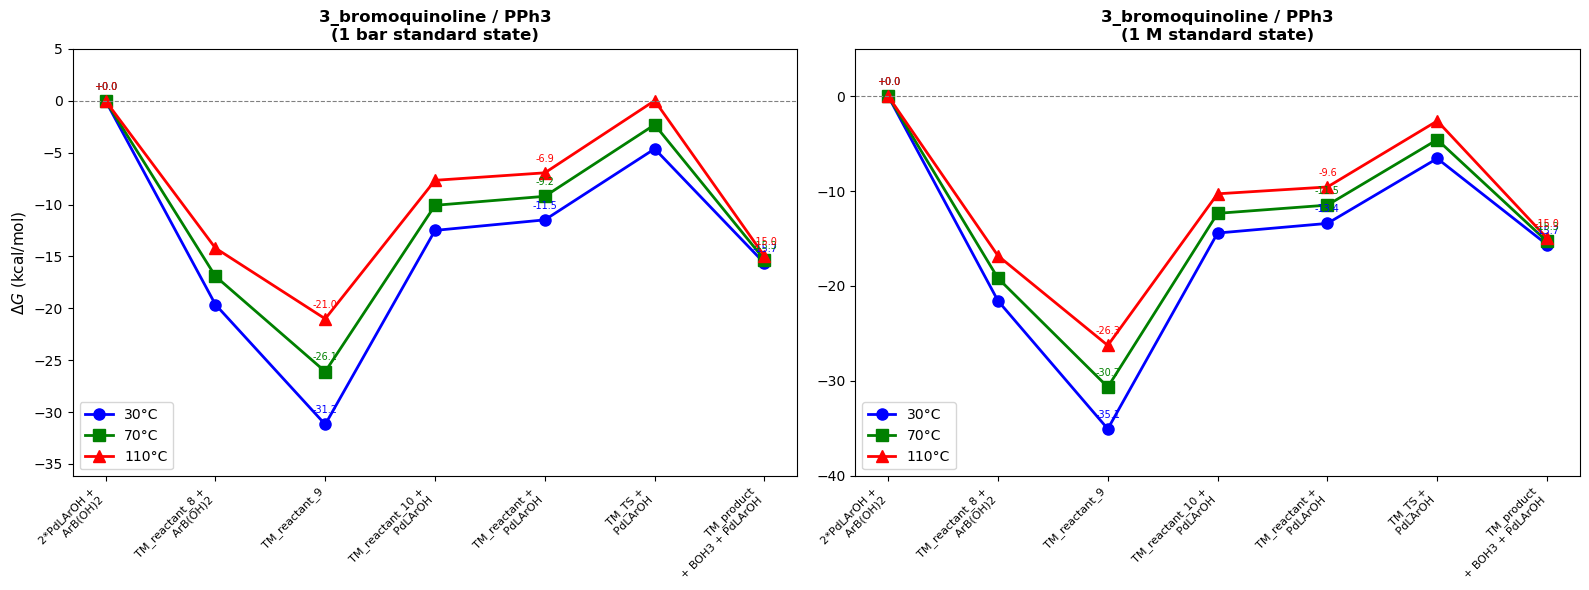

COMPARISON PLOT: PPh3, Case 2 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


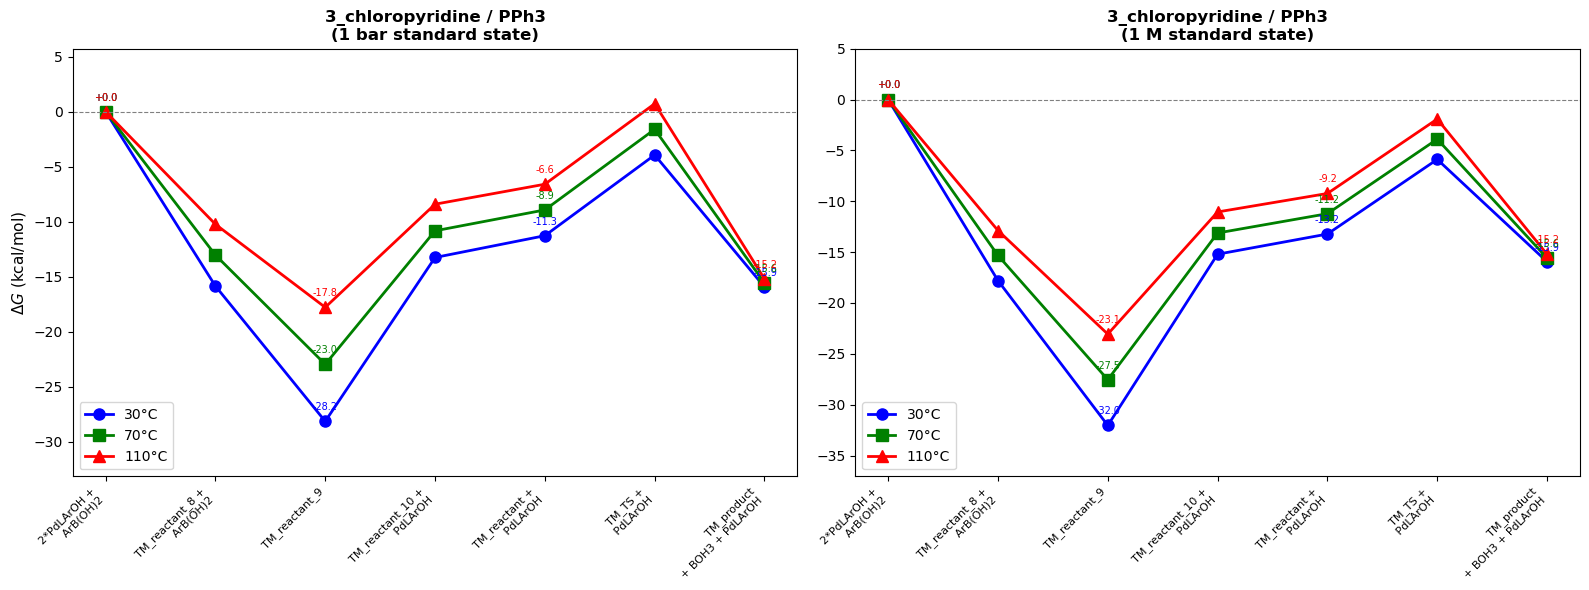

COMPARISON PLOT: PPh3, Case 3 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


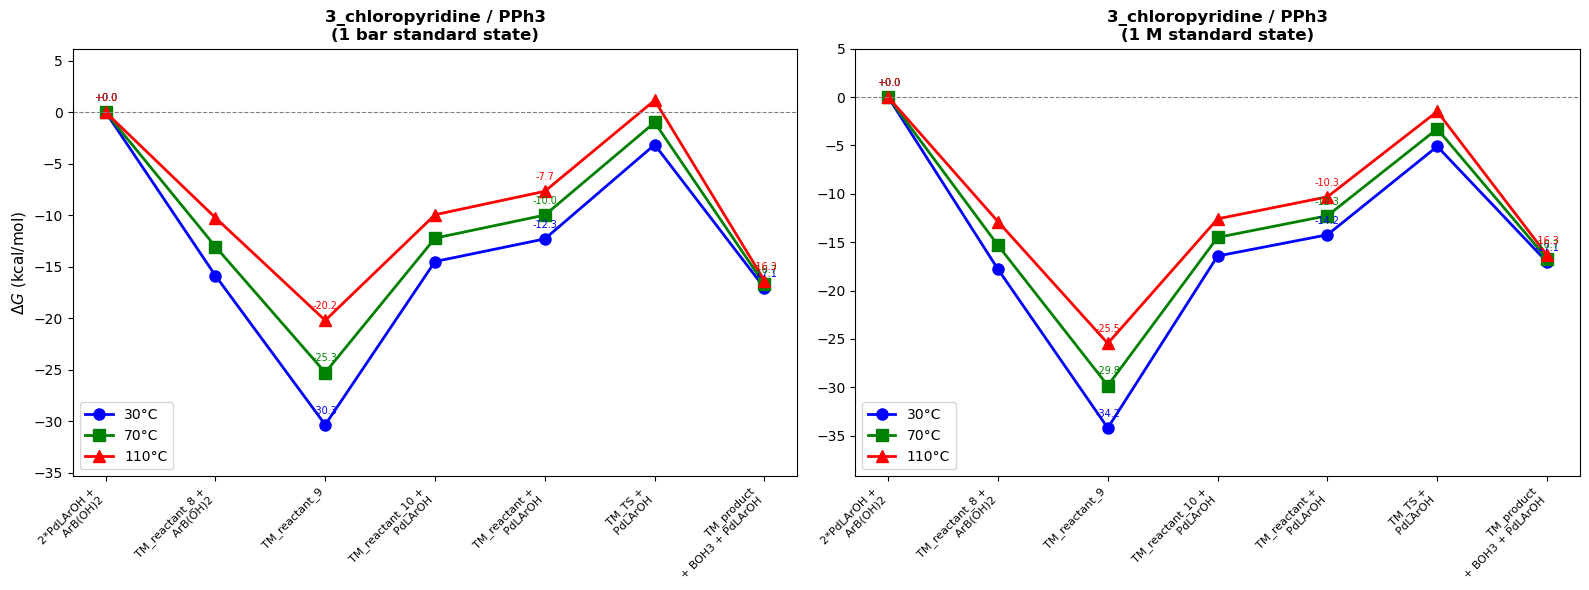

COMPARISON PLOT: PPh3, Case 4 (2_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


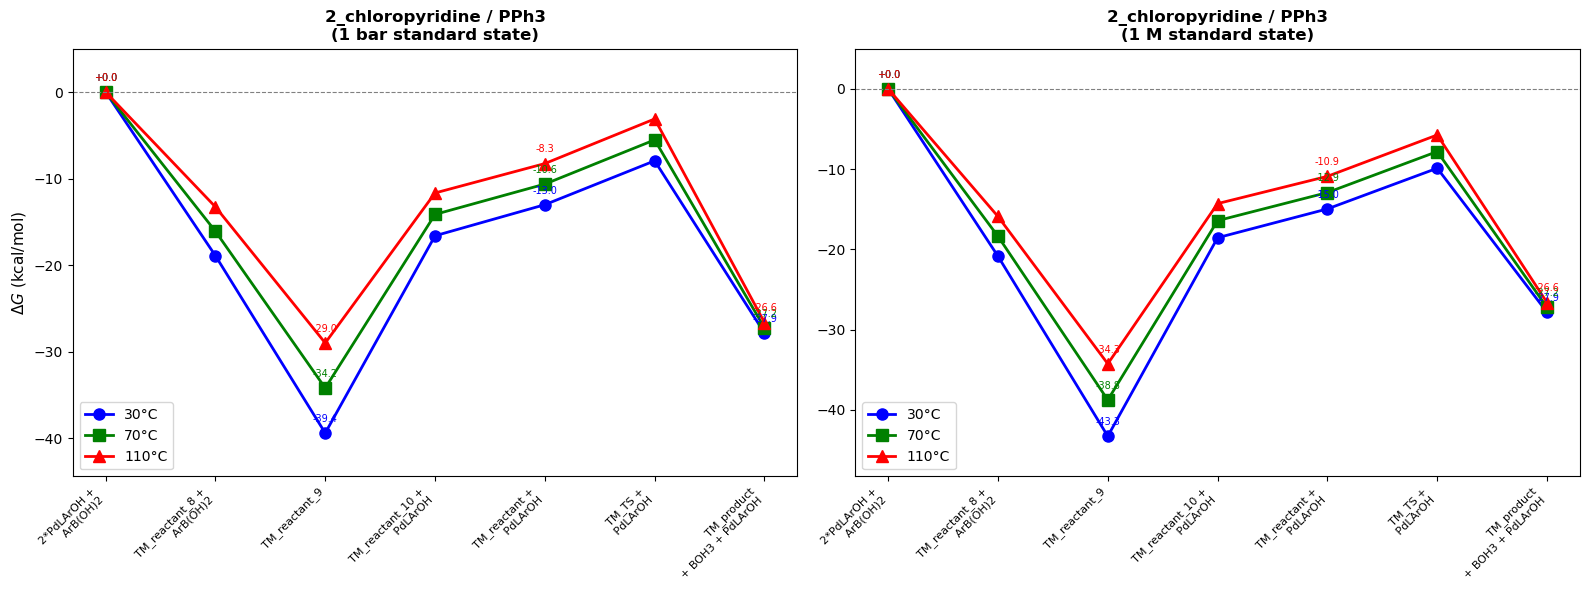


COMPARISON PLOT: tBu3, Case 4 (2_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


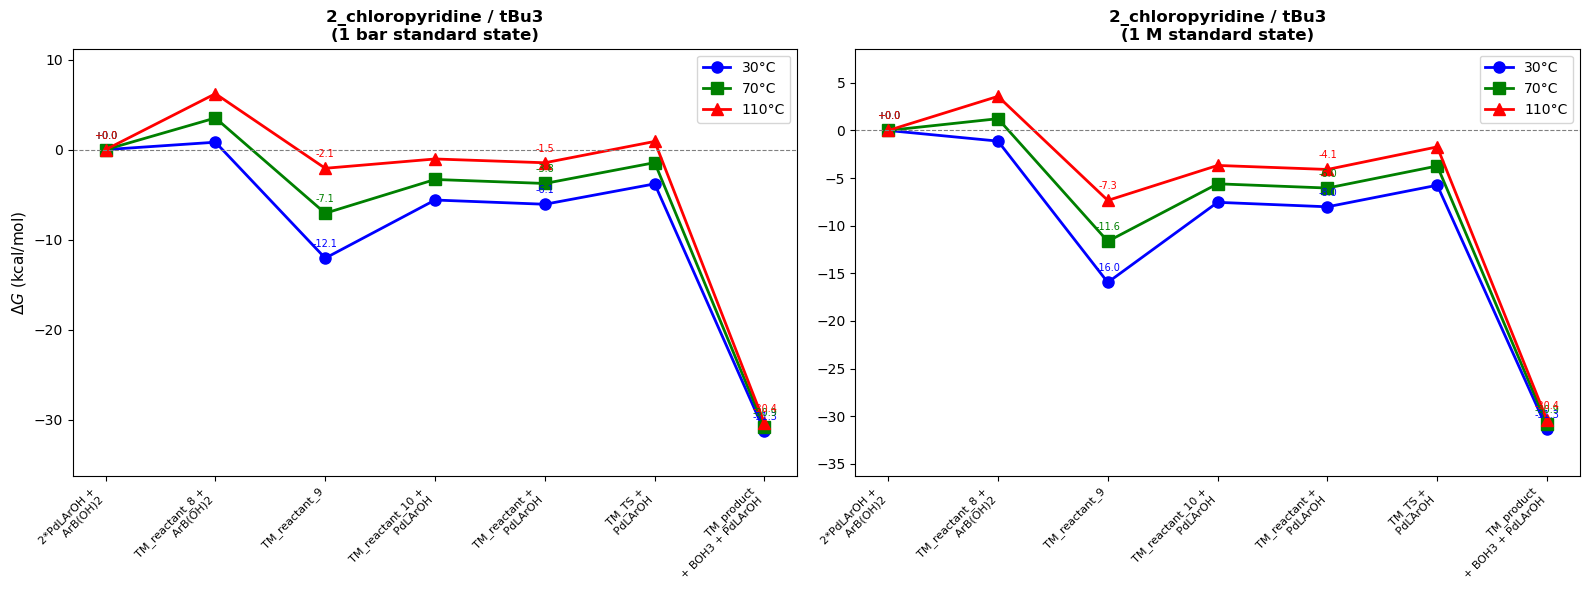


COMPARISON PLOT: SPhos, Case 3 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


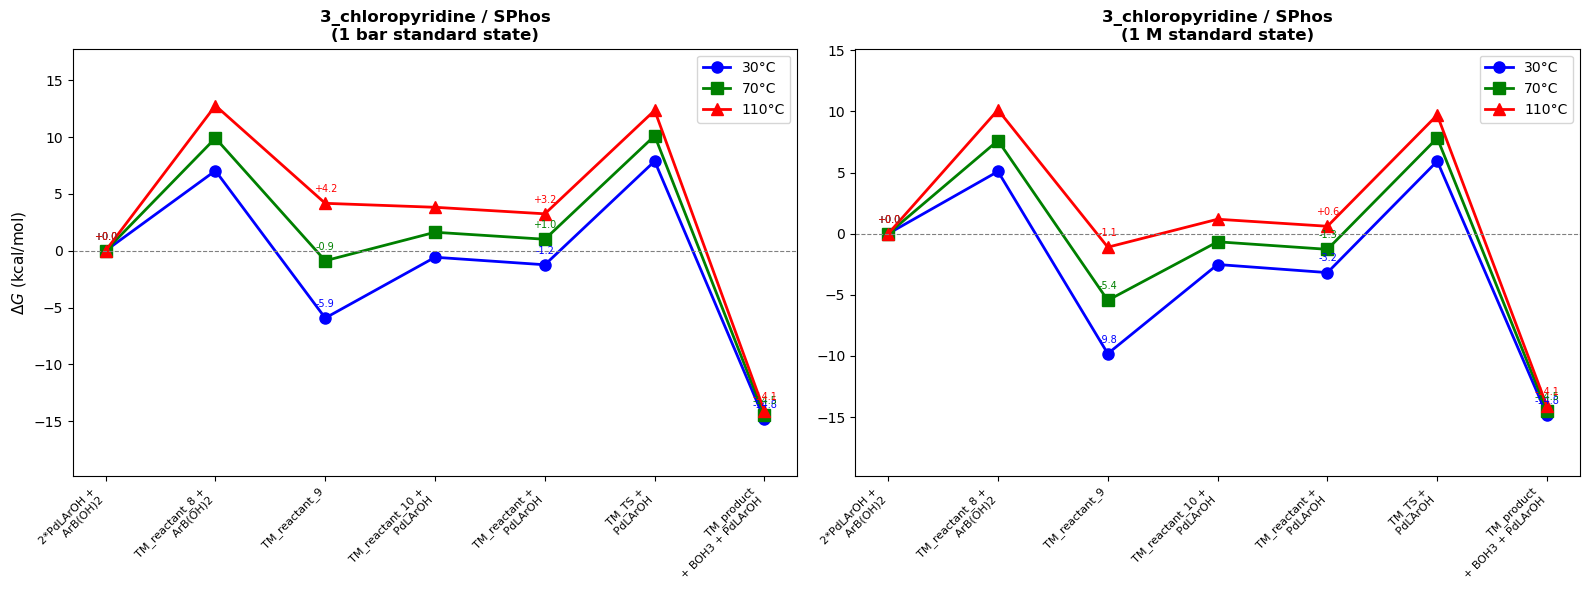


COMPARISON PLOT: PCy3, Case 2 (3_chloropyridine) - All temperatures


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\2556085504.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


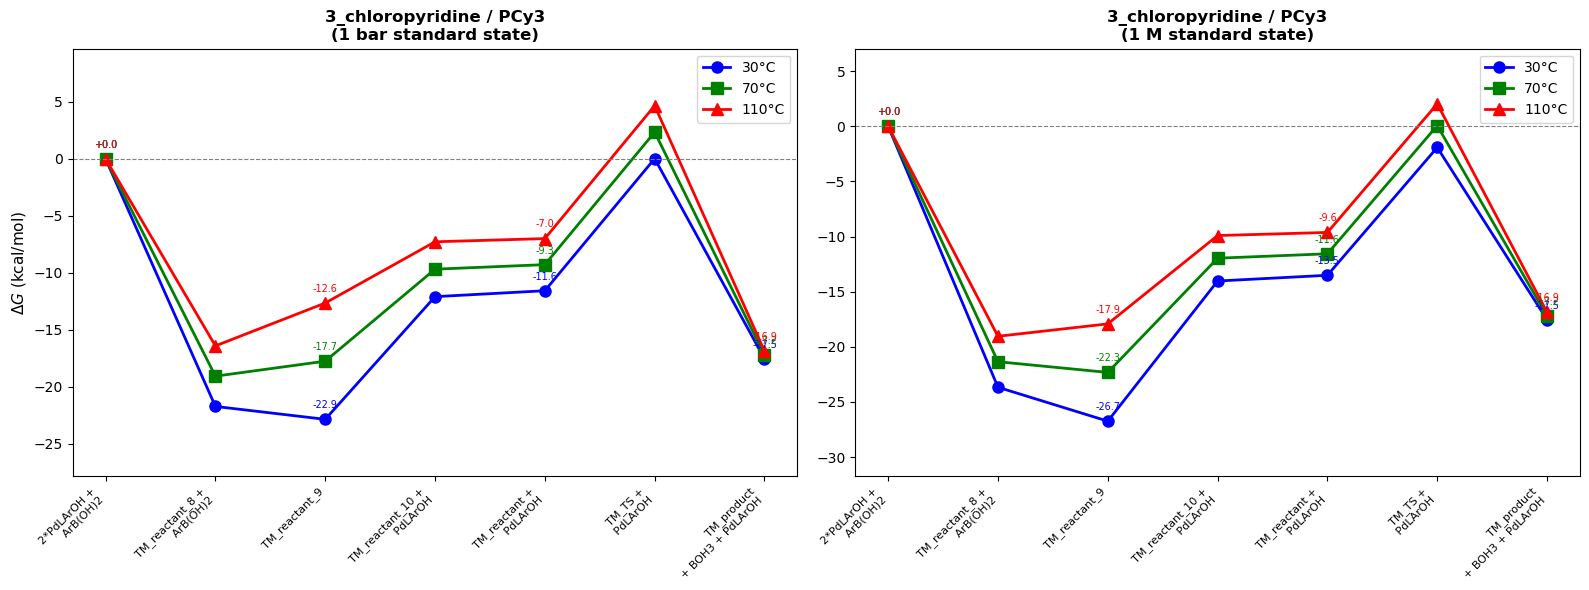

In [ ]:
def create_temperature_comparison_plots(ligand, case, temperatures=[30, 70, 110], df_corrections=None):
    """
    Create two plots side by side:
    - Left: 1 bar standard state with all temperatures on same plot
    - Right: 1 M standard state with all temperatures on same plot
    
    Uses your original plotting_TM_barriers_with_react9 style.
    """
    
    # Colors for different temperatures
    colors = {30: 'blue', 70: 'green', 110: 'red'}
    markers = {30: 'o', 70: 's', 110: '^'}
    
    # Common labels for all plots
    labels_tm = ["2*PdLArOH +\n ArB(OH)2",
                 "TM_reactant_8 +\n ArB(OH)2", 
                 "TM_reactant_9", 
                 "TM_reactant_10 +\n PdLArOH", 
                 "TM_reactant +\n PdLArOH", 
                 "TM_TS +\n PdLArOH", 
                 "TM_product\n+ BOH3 + PdLArOH"]
    
    x = [0, 1, 2, 3, 4, 5, 6]
    substrate_name = dict_tm_case[case][0]
    
    # Create figure with 1 row and 2 columns
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Store data for 1 bar and 1 M
    all_energies_1bar = {}
    all_energies_1M = {}
    
    for T in temperatures:
        # Get results for 1 bar (no correction)
        results_1bar = TM_barriers_with_react9(ligand, case, T,
                                               apply_standard_state_correction=False,
                                               df_corrections=None,
                                               verbose=False)
        
        # Get results for 1 M (with correction)
        results_1M = TM_barriers_with_react9(ligand, case, T,
                                             apply_standard_state_correction=True,
                                             df_corrections=df_corrections,
                                             verbose=False)
        
        # Store energies
        all_energies_1bar[T] = [0.0, 
                                results_1bar["dG_TM_react_8"], 
                                results_1bar["dG_TM_react_9"], 
                                results_1bar["dG_TM_reactant_10"], 
                                results_1bar["dG_TM_reactant"], 
                                results_1bar["dG_TM_TS"], 
                                results_1bar["dG_TM_product"]]
        
        all_energies_1M[T] = [0.0, 
                              results_1M["dG_TM_react_8"], 
                              results_1M["dG_TM_react_9"], 
                              results_1M["dG_TM_reactant_10"], 
                              results_1M["dG_TM_reactant"], 
                              results_1M["dG_TM_TS"], 
                              results_1M["dG_TM_product"]]
        
        # Plot on left axis (1 bar)
        ax_left.plot(x, all_energies_1bar[T], "o-", 
                    color=colors[T], linewidth=2, markersize=8, 
                    marker=markers[T], label=f"{T}°C")
        
        # Plot on right axis (1 M)
        ax_right.plot(x, all_energies_1M[T], "o-", 
                     color=colors[T], linewidth=2, markersize=8,
                     marker=markers[T], label=f"{T}°C")
    
    # Format left plot (1 bar)
    ax_left.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax_left.set_xticks(x)
    ax_left.set_xticklabels(labels_tm, fontsize=8, rotation=45, ha='right')
    ax_left.set_ylabel(r"$\Delta G$ (kcal/mol)", fontsize=11)
    ax_left.set_title(f"{substrate_name} / {ligand}\n(1 bar standard state)", 
                     fontsize=12, fontweight='bold')
    ax_left.legend(fontsize=10, loc='best')
    
    # Add value annotations for 1 bar plot
    for T in temperatures:
        for xi, yi in zip(x, all_energies_1bar[T]):
            if xi % 2 == 0:  # Only annotate every other point to avoid clutter
                ax_left.annotate(f"{yi:+.1f}", (xi, yi),
                                textcoords="offset points", xytext=(0, 8), 
                                ha="center", fontsize=7, color=colors[T])
    
    # Set y-limits for left plot
    all_values_1bar = [val for energies in all_energies_1bar.values() for val in energies]
    ax_left.set_ylim(min(all_values_1bar)-5, max(all_values_1bar)+5)
    
    # Format right plot (1 M)
    ax_right.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax_right.set_xticks(x)
    ax_right.set_xticklabels(labels_tm, fontsize=8, rotation=45, ha='right')
    ax_right.set_title(f"{substrate_name} / {ligand}\n(1 M standard state)", 
                      fontsize=12, fontweight='bold')
    ax_right.legend(fontsize=10, loc='best')
    
    # Add value annotations for 1 M plot
    for T in temperatures:
        for xi, yi in zip(x, all_energies_1M[T]):
            if xi % 2 == 0:  # Only annotate every other point to avoid clutter
                ax_right.annotate(f"{yi:+.1f}", (xi, yi),
                                textcoords="offset points", xytext=(0, 8), 
                                ha="center", fontsize=7, color=colors[T])
    
    # Set y-limits for right plot
    all_values_1M = [val for energies in all_energies_1M.values() for val in energies]
    ax_right.set_ylim(min(all_values_1M)-5, max(all_values_1M)+5)
    
    plt.tight_layout()
    plt.show()

# Load standard state corrections
corrections_path = r"standard_state_correction_factors_20C_120C.csv"
df_corrections = load_standard_state_corrections(corrections_path)
df_corrections = load_standard_state_corrections(corrections_path)

# Example 1: Plot for PPh3, all cases with all temperatures on same graph
print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 1 (3_bromoquinoline)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case1", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 2 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case2", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 3 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case3", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 4 (2_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case4", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)


# Example 2: Plot for tBu3, case4 (2_chloropyridine - had lowest barrier)
print("\n" + "=" * 80)
print("COMPARISON PLOT: tBu3, Case 4 (2_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="tBu3", case="case4", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

# Example 3: Plot for SPhos, case3 (3_chloropyridine)
print("\n" + "=" * 80)
print("COMPARISON PLOT: SPhos, Case 3 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="SPhos", case="case3", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

# Example 4: Plot for PCy3, case2 with all 5 temperatures
print("\n" + "=" * 80)
print("COMPARISON PLOT: PCy3, Case 2 (3_chloropyridine) - All temperatures")
print("=" * 80)
create_temperature_comparison_plots(ligand="PCy3", case="case2", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

COMPARISON PLOT: PPh3, Case 1 (3_bromoquinoline)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


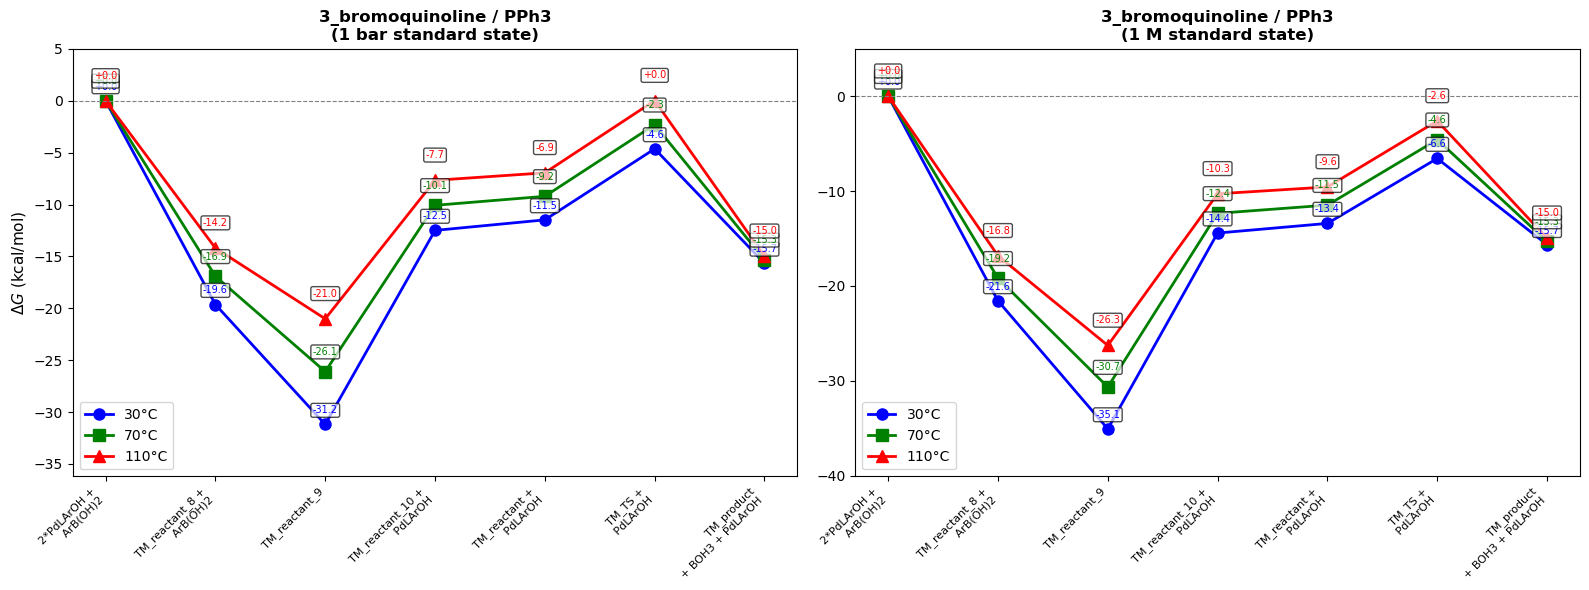

COMPARISON PLOT: PPh3, Case 2 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


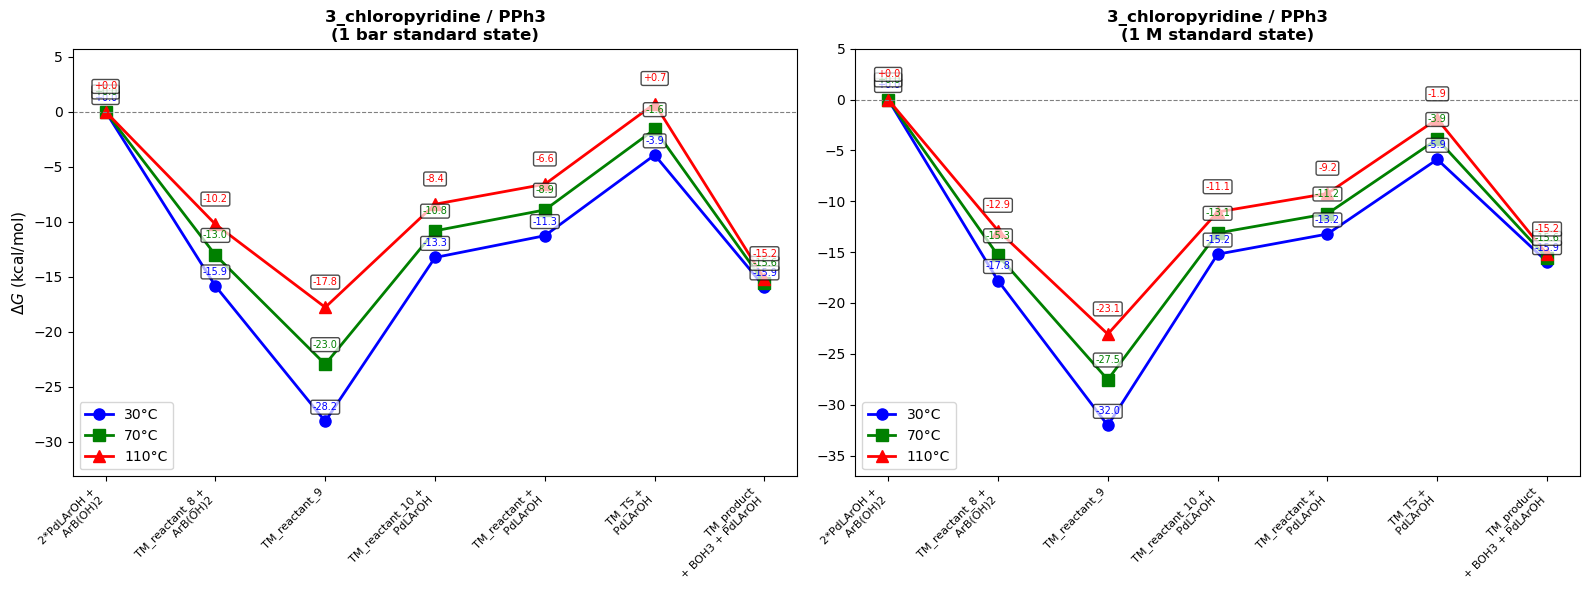

COMPARISON PLOT: PPh3, Case 3 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


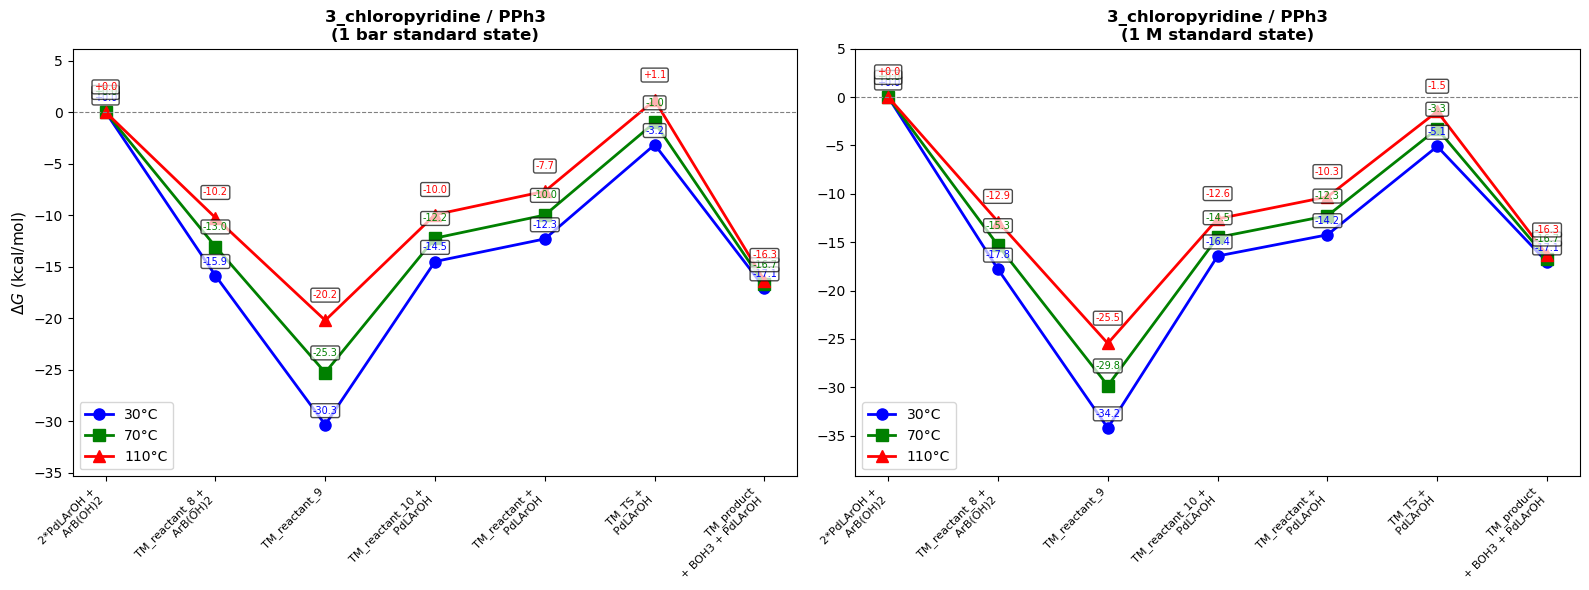

COMPARISON PLOT: PPh3, Case 4 (2_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


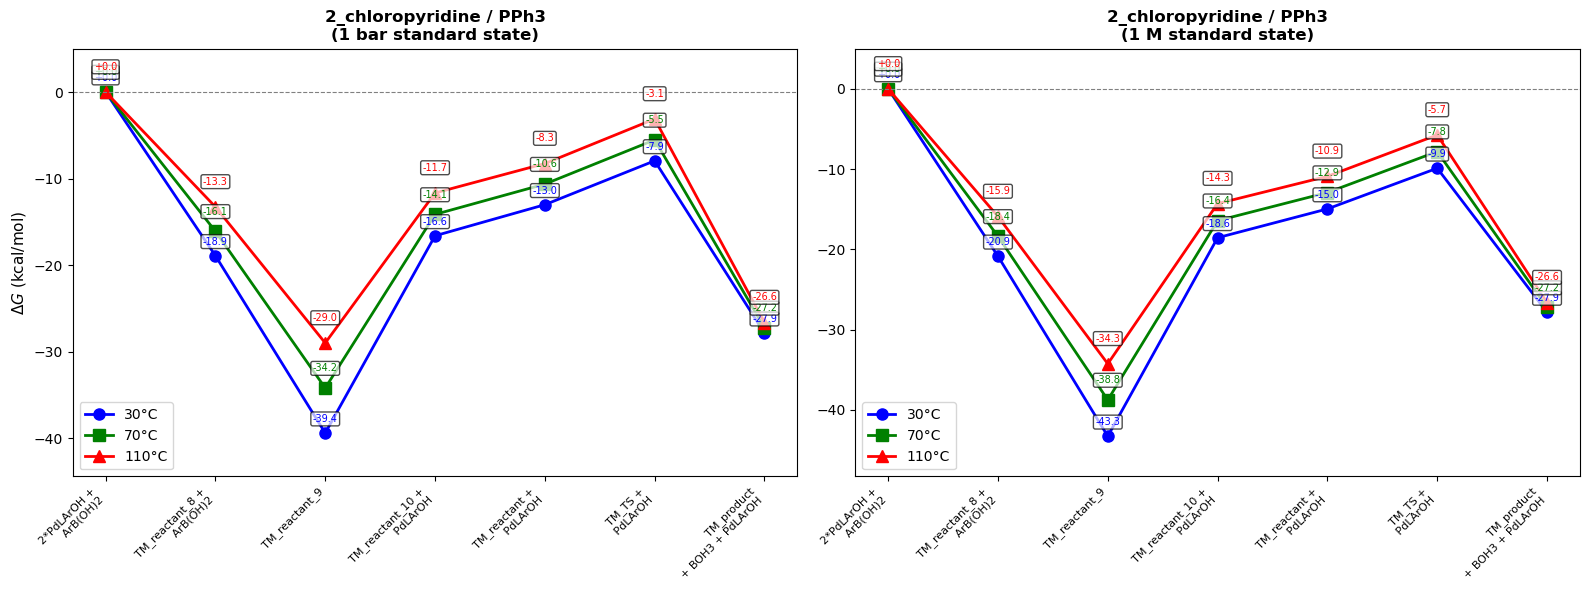


COMPARISON PLOT: tBu3, Case 4 (2_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


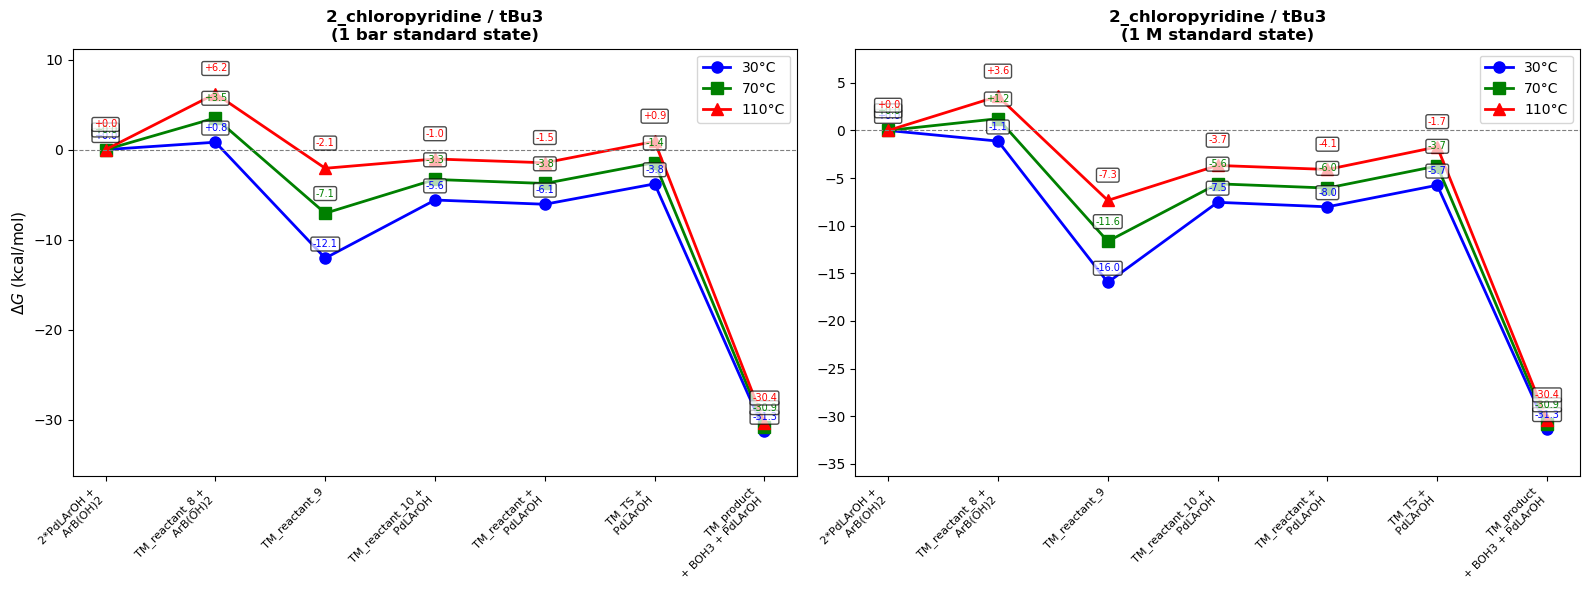


COMPARISON PLOT: SPhos, Case 3 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


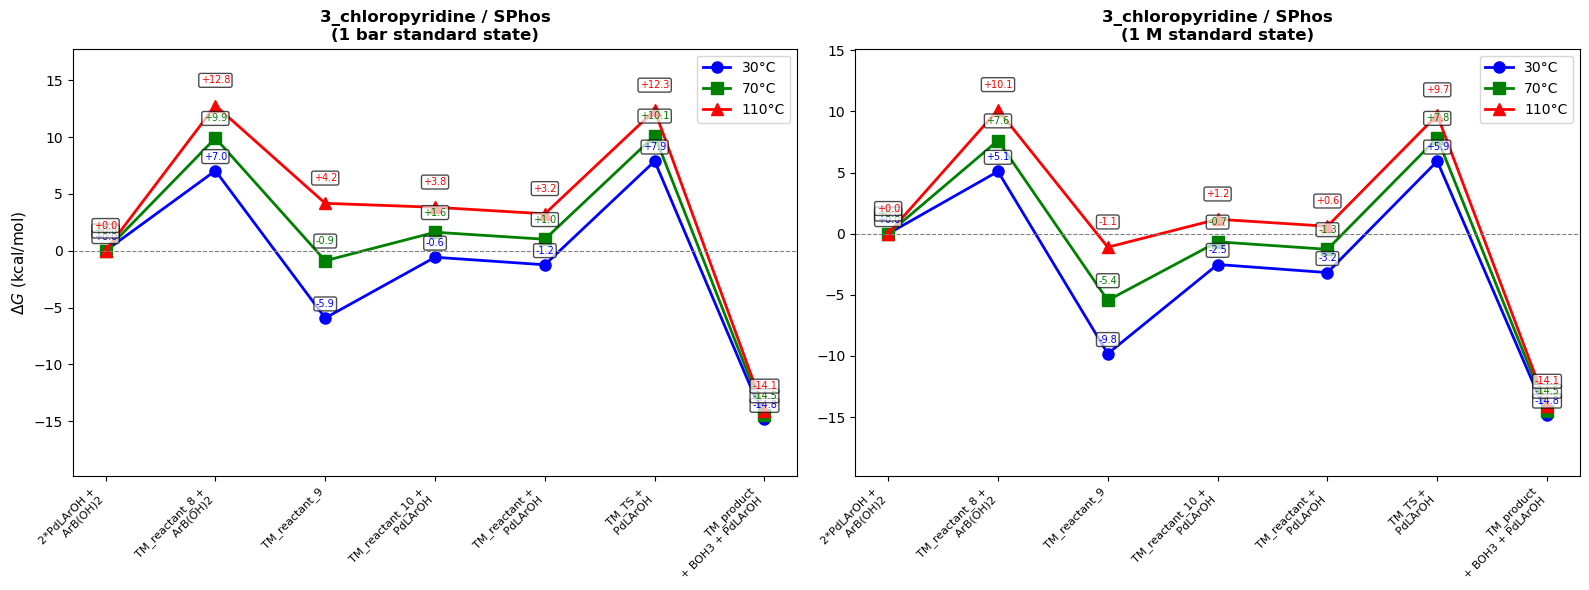


COMPARISON PLOT: PCy3, Case 2 (3_chloropyridine)


C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:64: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_left.plot(x, all_energies_1bar[T], "o-",
C:\Users\livio\AppData\Local\Temp\ipykernel_6740\3508577365.py:69: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax_right.plot(x, all_energies_1M[T], "o-",


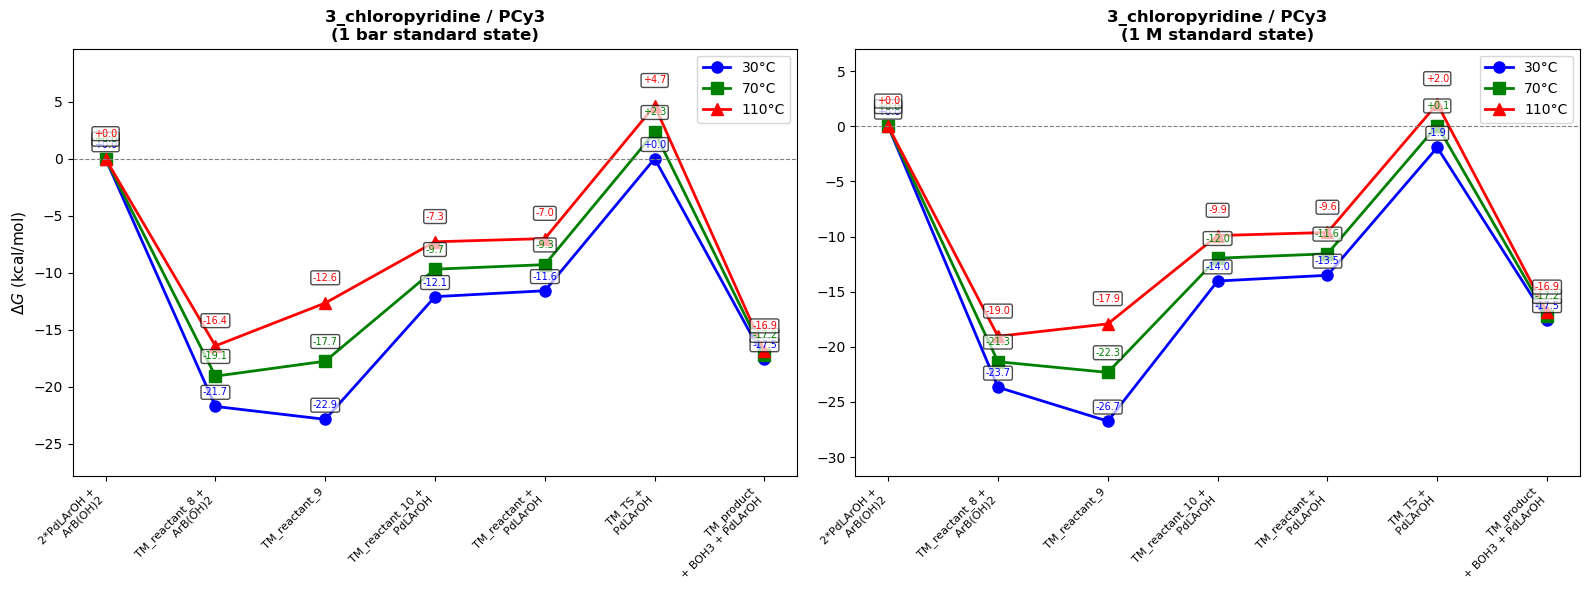

In [ ]:
def create_temperature_comparison_plots(ligand, case, temperatures=[30, 70, 110], df_corrections=None):
    """
    Create two plots side by side:
    - Left: 1 bar standard state with all temperatures on same plot
    - Right: 1 M standard state with all temperatures on same plot
    
    Uses your original plotting_TM_barriers_with_react9 style.
    """
    
    # Colors for different temperatures
    colors = {30: 'blue', 70: 'green', 110: 'red'}
    markers = {30: 'o', 70: 's', 110: '^'}
    
    # Common labels for all plots
    labels_tm = ["2*PdLArOH +\n ArB(OH)2",
                 "TM_reactant_8 +\n ArB(OH)2", 
                 "TM_reactant_9", 
                 "TM_reactant_10 +\n PdLArOH", 
                 "TM_reactant +\n PdLArOH", 
                 "TM_TS +\n PdLArOH", 
                 "TM_product\n+ BOH3 + PdLArOH"]
    
    x = [0, 1, 2, 3, 4, 5, 6]
    substrate_name = dict_tm_case[case][0]
    
    # Create figure with 1 row and 2 columns
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Store data for 1 bar and 1 M
    all_energies_1bar = {}
    all_energies_1M = {}
    
    for T in temperatures:
        # Get results for 1 bar (no correction)
        results_1bar = TM_barriers_with_react9(ligand, case, T,
                                               apply_standard_state_correction=False,
                                               df_corrections=None,
                                               verbose=False)
        
        # Get results for 1 M (with correction)
        results_1M = TM_barriers_with_react9(ligand, case, T,
                                             apply_standard_state_correction=True,
                                             df_corrections=df_corrections,
                                             verbose=False)
        
        # Store energies
        all_energies_1bar[T] = [0.0, 
                                results_1bar["dG_TM_react_8"], 
                                results_1bar["dG_TM_react_9"], 
                                results_1bar["dG_TM_reactant_10"], 
                                results_1bar["dG_TM_reactant"], 
                                results_1bar["dG_TM_TS"], 
                                results_1bar["dG_TM_product"]]
        
        all_energies_1M[T] = [0.0, 
                              results_1M["dG_TM_react_8"], 
                              results_1M["dG_TM_react_9"], 
                              results_1M["dG_TM_reactant_10"], 
                              results_1M["dG_TM_reactant"], 
                              results_1M["dG_TM_TS"], 
                              results_1M["dG_TM_product"]]
        
        # Plot on left axis (1 bar)
        ax_left.plot(x, all_energies_1bar[T], "o-", 
                    color=colors[T], linewidth=2, markersize=8, 
                    marker=markers[T], label=f"{T}°C")
        
        # Plot on right axis (1 M)
        ax_right.plot(x, all_energies_1M[T], "o-", 
                     color=colors[T], linewidth=2, markersize=8,
                     marker=markers[T], label=f"{T}°C")
    
    # Format left plot (1 bar)
    ax_left.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax_left.set_xticks(x)
    ax_left.set_xticklabels(labels_tm, fontsize=8, rotation=45, ha='right')
    ax_left.set_ylabel(r"$\Delta G$ (kcal/mol)", fontsize=11)
    ax_left.set_title(f"{substrate_name} / {ligand}\n(1 bar standard state)", 
                     fontsize=12, fontweight='bold')
    ax_left.legend(fontsize=10, loc='best')
    
    # Add value annotations for 1 bar plot - NOW FOR ALL POINTS
    for T in temperatures:
        for xi, yi in zip(x, all_energies_1bar[T]):
            # Offset annotations slightly based on temperature to avoid overlap
            y_offset = 8 if T == 30 else (12 if T == 70 else 16)
            ax_left.annotate(f"{yi:+.1f}", (xi, yi),
                            textcoords="offset points", xytext=(0, y_offset), 
                            ha="center", fontsize=7, color=colors[T],
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    # Set y-limits for left plot
    all_values_1bar = [val for energies in all_energies_1bar.values() for val in energies]
    ax_left.set_ylim(min(all_values_1bar)-5, max(all_values_1bar)+5)
    
    # Format right plot (1 M)
    ax_right.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax_right.set_xticks(x)
    ax_right.set_xticklabels(labels_tm, fontsize=8, rotation=45, ha='right')
    ax_right.set_title(f"{substrate_name} / {ligand}\n(1 M standard state)", 
                      fontsize=12, fontweight='bold')
    ax_right.legend(fontsize=10, loc='best')
    
    # Add value annotations for 1 M plot - NOW FOR ALL POINTS
    for T in temperatures:
        for xi, yi in zip(x, all_energies_1M[T]):
            # Offset annotations slightly based on temperature to avoid overlap
            y_offset = 8 if T == 30 else (12 if T == 70 else 16)
            ax_right.annotate(f"{yi:+.1f}", (xi, yi),
                            textcoords="offset points", xytext=(0, y_offset), 
                            ha="center", fontsize=7, color=colors[T],
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
    
    # Set y-limits for right plot
    all_values_1M = [val for energies in all_energies_1M.values() for val in energies]
    ax_right.set_ylim(min(all_values_1M)-5, max(all_values_1M)+5)
    
    plt.tight_layout()
    plt.show()

# Load standard state corrections
corrections_path = r"standard_state_correction_factors_20C_120C.csv"
df_corrections = load_standard_state_corrections(corrections_path)

# Example 1: Plot for PPh3, case1
print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 1 (3_bromoquinoline)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case1", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 2 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case2", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 3 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case3", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

print("=" * 80)
print("COMPARISON PLOT: PPh3, Case 4 (2_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PPh3", case="case4", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

# Example 2: Plot for tBu3, case4 (had lowest barrier)
print("\n" + "=" * 80)
print("COMPARISON PLOT: tBu3, Case 4 (2_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="tBu3", case="case4", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

# Example 3: Plot for SPhos, case3
print("\n" + "=" * 80)
print("COMPARISON PLOT: SPhos, Case 3 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="SPhos", case="case3", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)

# Example 4: Plot for PCy3, case2
print("\n" + "=" * 80)
print("COMPARISON PLOT: PCy3, Case 2 (3_chloropyridine)")
print("=" * 80)
create_temperature_comparison_plots(ligand="PCy3", case="case2", 
                                   temperatures=[30, 70, 110], 
                                   df_corrections=df_corrections)